# Network Intrusion Detection (ML)
This notebook performs EDA, preprocessing, and builds classification models for Network Intrusion Detection. We use NSL-KDD and CIC-IDS2017 datasets.

## 1. Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading
Loading the datasets. NSL-KDD is fetched from a raw Github link for demonstration. CIC-IDS2017 should be placed locally due to its large size.

In [ ]:
# 1. Loading NSL-KDD Dataset
# We use a raw github link for demonstration purposes.
nsl_kdd_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.csv"
columns = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
           'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
           'root_shell','su_attempted','num_root','num_file_creations','num_shells',
           'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
           'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
           'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
           'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
           'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
           'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','target','level']

print("Loading NSL-KDD Dataset...")
try:
    df_nsl = pd.read_csv(nsl_kdd_url, names=columns)
    # Sample down for faster demonstration
    df_nsl = df_nsl.sample(n=25000, random_state=42).reset_index(drop=True)
    print("NSL-KDD Dataset loaded successfully! Shape:", df_nsl.shape)
except Exception as e:
    print("Error loading NSL-KDD. Error:", e)

Loading NSL-KDD Dataset...
NSL-KDD Dataset loaded successfully! Shape: (25000, 43)


In [ ]:
# 2. Loading CIC-IDS2017 Dataset
import os
# Since CIC-IDS2017 is huge, we provide the code to load it assuming it's downloaded locally.
cic_file_path = "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
df_cic = None

if os.path.exists(cic_file_path):
    print("Loading CIC-IDS2017 Dataset...")
    df_cic = pd.read_csv(cic_file_path)
    print("CIC-IDS2017 Dataset loaded! Shape:", df_cic.shape)
else:
    print(f"CIC-IDS2017 file '{cic_file_path}' not found locally.")
    print("Please download it from the UNB CIC website and place it in the same directory.")
    print("For this notebook, we will proceed with the full pipeline on the NSL-KDD dataset.")

CIC-IDS2017 file 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv' not found locally.
Please download it from the UNB CIC website and place it in the same directory.
For this notebook, we will proceed with the full pipeline on the NSL-KDD dataset.


## 3. Exploratory Data Analysis (EDA)

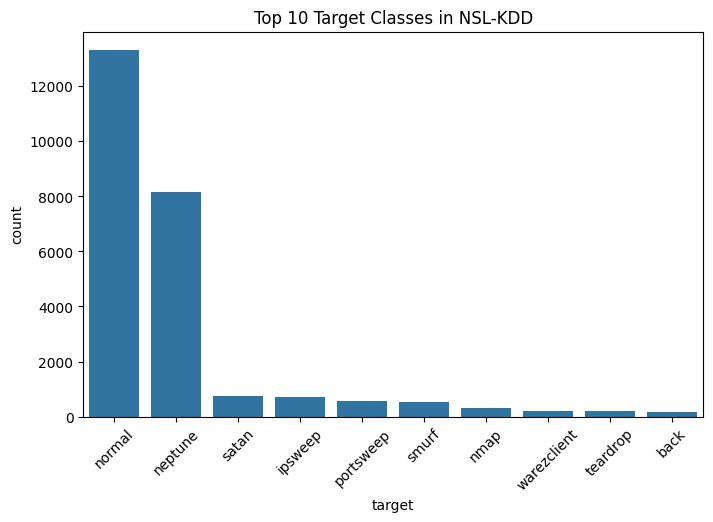

In [ ]:
# 3. Exploratory Data Analysis (EDA) on NSL-KDD
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df_nsl, order=df_nsl['target'].value_counts().iloc[:10].index)
plt.title("Top 10 Target Classes in NSL-KDD")
plt.xticks(rotation=45)
plt.show()

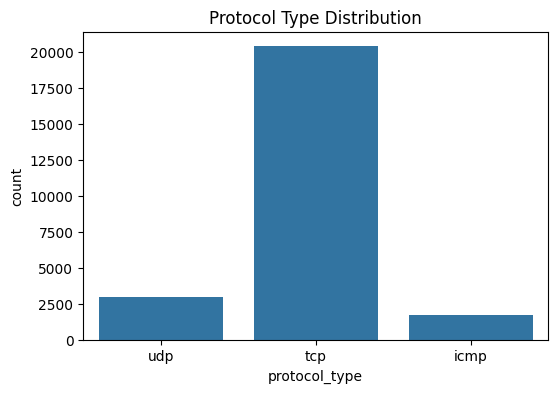

In [ ]:
# Plotting Protocol Types
plt.figure(figsize=(6, 4))
sns.countplot(x='protocol_type', data=df_nsl)
plt.title("Protocol Type Distribution")
plt.show()

In [ ]:
# Binary classification mapping
# Normal vs Attack
df_nsl['attack_flag'] = df_nsl.target.apply(lambda x: 0 if x == 'normal' else 1)
print("Distribution of Normal vs Attack:")
print(df_nsl['attack_flag'].value_counts(normalize=True))

Distribution of Normal vs Attack:
attack_flag
0    0.53256
1    0.46744
Name: proportion, dtype: float64


## 4. Preprocessing Pipeline
Handling categorical variables and scaling numerical features.

In [ ]:
# 4. Data Preprocessing Pipeline
# Drop columns that are mostly zero or redundant
cols_to_drop = ['target', 'level', 'num_outbound_cmds', 'attack_flag']
X = df_nsl.drop(columns=cols_to_drop, errors='ignore')
y = df_nsl['attack_flag']

# Identify categorical columns
cat_cols = ['protocol_type', 'service', 'flag']

# Label Encoding for categorical variables
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

print("Categorical columns encoded.")

Categorical columns encoded.


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (20000, 40)
Testing data shape: (5000, 40)


## 5. Model Training & Evaluation
Training Logistic Regression, Random Forest, and XGBoost.

In [ ]:
# 5. Modeling & Evaluation
# Baseline Model: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Logistic Regression Performance:")
print(classification_report(y_test, lr_preds))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      2641
           1       0.96      0.94      0.95      2359

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000



In [ ]:
# Advanced Model: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print("Random Forest Performance:")
print(classification_report(y_test, rf_preds))

Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2641
           1       1.00      1.00      1.00      2359

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



In [ ]:
# State-of-the-art Model: XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

print("XGBoost Performance:")
print(classification_report(y_test, xgb_preds))

XGBoost Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2641
           1       1.00      1.00      1.00      2359

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



## 6. Feature Engineering & Importance
Analyzing the most important features detected by the Random Forest model.

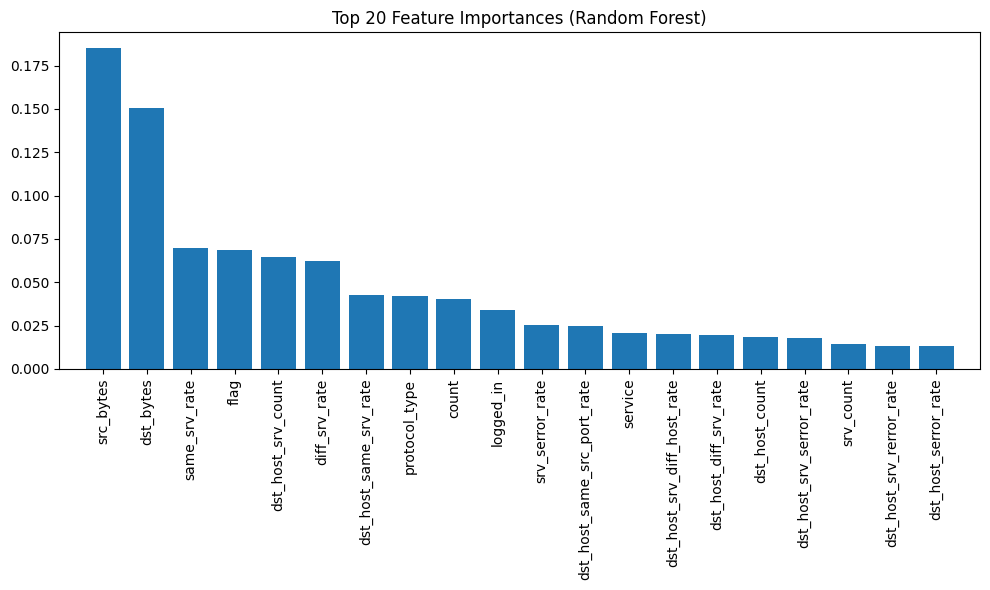

In [ ]:
# 6. Feature Engineering & Importance (from Random Forest)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.xlim([-1, 20])
plt.tight_layout()
plt.show()

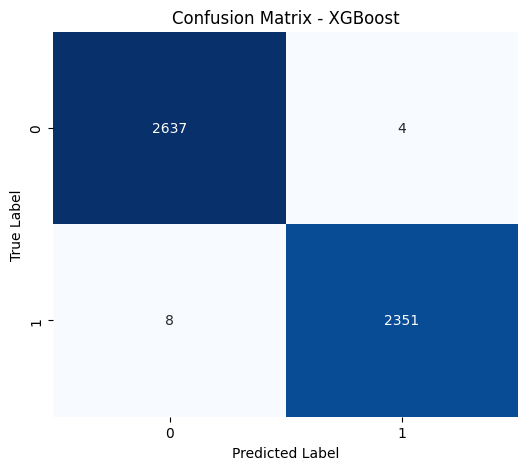

In [ ]:
# Confusion Matrix for XGBoost
cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()